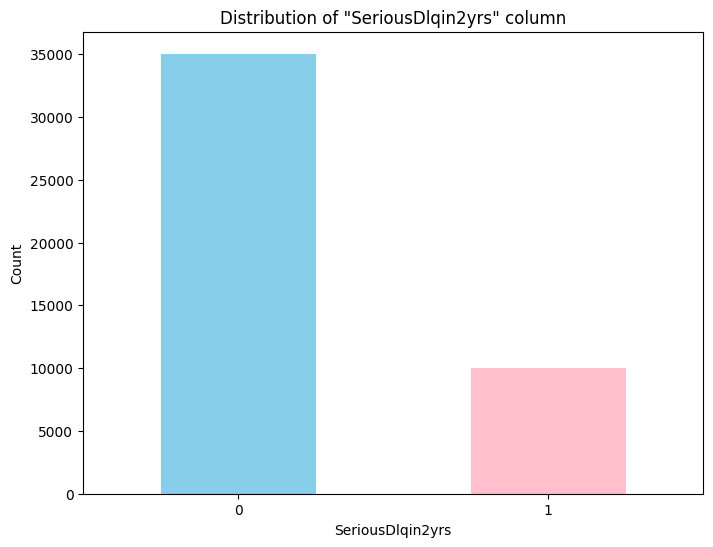


Few rows of raw dataset:

   SeriousDlqin2yrs  age  NumberOfTime30-59DaysPastDueNotWorse    DebtRatio  \
0                 0   64                                     0     0.249908   
1                 0   58                                     0  3870.000000   
2                 0   41                                     0     0.456127   
3                 0   43                                     0     0.000190   
4                 1   49                                     0     0.271820   

   NumberOfTimes90DaysLate  NumberOfTime60-89DaysPastDueNotWorse  \
0                        0                                     0   
1                        0                                     0   
2                        0                                     0   
3                        0                                     0   
4                        0                                     0   

   MonthlyIncome  NumberOfDependents  
0         8158.0                 0.0  
1          

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/drive/MyDrive/credit_scoring_sample.csv"
data = pd.read_csv(file_path, sep=";")

# Plotting distribution of target column (SeriousDlqin2yrs)
plt.figure(figsize=(8, 6))
data['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['skyblue', 'pink'])
plt.title('Distribution of "SeriousDlqin2yrs" column')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# first few rows of raw dataset
print("\nFew rows of raw dataset:\n")
print(data.head())

# replace NaN values with median of each column
data.fillna(data.median(), inplace=True)

print("\n\n==========================================\nFew rows of dataset after replacing NaN values:\n")
# first few rows of dataset after replacing NaN values
print(data.head())


### **1- Bootstrapping**

In [12]:
import numpy as np

delinquent_customers = data[data['SeriousDlqin2yrs'] == 1] # extract delinquent customers

# bootstrapping sampling
def bootstrap_mean(data, n_bootstrap):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))
    return bootstrap_means

# bootstrap samples and mean age for each
n_bootstrap = 1000
bootstrap_means = bootstrap_mean(delinquent_customers['age'], n_bootstrap)

# Computing confidence interval
confidence_level = 0.90
alpha = 1 - confidence_level
lower_percentile = alpha / 2 * 100
upper_percentile = (1 - alpha / 2) * 100
lower_bound = np.percentile(bootstrap_means, lower_percentile)
upper_bound = np.percentile(bootstrap_means, upper_percentile)

print(f"90% confidence interval \nfor mean age of delinquent customers  ===> [{lower_bound:.4f}, {upper_bound:.4f}]")

90% confidence interval 
for mean age of delinquent customers  ===> [45.7148, 46.1345]


### **2- Random Forest**

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

# set parameters
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
parameters = {'max_features': [1, 2, 4],
              'min_samples_leaf': [3, 5, 7, 9],
              'max_depth': [5, 10, 15]}

# Grid Search with 5-fold stratified cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                           n_jobs=-1, scoring='roc_auc')

# splitting data (80% for training)
X = data.drop(columns=['SeriousDlqin2yrs'])
y = data['SeriousDlqin2yrs']
train_size = int(0.8 * len(data))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

grid_search.fit(X_train, y_train) # grid search on data

# get best estimator and its ROC AUC score
best_rf = grid_search.best_estimator_
roc_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
print("(Random Forest Classifier)")
print("Best Parameters:", grid_search.best_params_)
print("ROC AUC Score:", roc_auc)

(Random Forest Classifier)
Best Parameters: {'max_depth': 10, 'max_features': 2, 'min_samples_leaf': 9}
ROC AUC Score: 0.833412274088088


### **3- Feature with weakest impact**

In [14]:
# feature importances
feature_importances = best_rf.feature_importances_

# dataframe for display feature importances
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False) # Sort descending
print("Feature importances:\n", importance_df)

importance_df = importance_df.sort_values(by='Importance', ascending=True) # Sort ascending
print("\n------------------------------------------------------\nFeature with weakest impact:\n", importance_df.iloc[0]['Feature'], "(", importance_df.iloc[0]['Importance'], ")")

Feature importances:
                                 Feature  Importance
1  NumberOfTime30-59DaysPastDueNotWorse    0.284943
3               NumberOfTimes90DaysLate    0.278681
4  NumberOfTime60-89DaysPastDueNotWorse    0.150848
0                                   age    0.115671
2                             DebtRatio    0.087404
5                         MonthlyIncome    0.064941
6                    NumberOfDependents    0.017511

------------------------------------------------------
Feature with weakest impact:
 NumberOfDependents ( 0.017510841832160555 )


### **4- Bagging**

base_estimator__C

In [5]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from scipy.stats import uniform
import warnings
from sklearn.exceptions import ConvergenceWarning

# suppress FutureWarning for base_estimator
warnings.filterwarnings(action='ignore', category=FutureWarning)

# set parameters
parameters = {
    'max_features': [2, 3, 4],
    'max_samples': [0.5, 0.7, 0.9],
    'base_estimator__C': [0.0001, 0.001, 0.01, 1, 10, 100]
}

base_estimator = LogisticRegression() # base estimator
bagging = BaggingClassifier(base_estimator=base_estimator, n_estimators=100) # bagging classifier

# Randomized Search with 5-fold stratified cross-validation
random_search = RandomizedSearchCV(estimator=bagging, param_distributions=parameters,
                                   n_iter=20, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc', n_jobs=-1)

# Randomized Search on data
random_search.fit(X_train, y_train)

# get best estimator and its ROC AUC score
best_bagging = random_search.best_estimator_
roc_auc = roc_auc_score(y_test, best_bagging.predict_proba(X_test)[:, 1])
print("Best Parameters:", random_search.best_params_)
print("ROC AUC Score of Best Bagging Classifier:", roc_auc)

Best Parameters: {'max_samples': 0.5, 'max_features': 2, 'base_estimator__C': 100}
ROC AUC Score of Best Bagging Classifier: 0.7864171482136183



---

Updated version:

estimator__C

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from scipy.stats import uniform

# set parameters
parameters = {
    'max_features': [2, 3, 4],
    'max_samples': [0.5, 0.7, 0.9],
    'estimator__C': [0.0001, 0.001, 0.01, 1, 10, 100]
}

bagging = BaggingClassifier(LogisticRegression(), n_estimators=100) #  bagging classifier

# Randomized Search with 5-fold stratified cross-validation
random_search = RandomizedSearchCV(estimator=bagging, param_distributions=parameters,
                                   n_iter=20, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc', n_jobs=-1)

# Randomized Search on data
random_search.fit(X_train, y_train)

# get best estimator and its ROC AUC score
best_bagging = random_search.best_estimator_
roc_auc = roc_auc_score(y_test, best_bagging.predict_proba(X_test)[:, 1])
print("Best Parameters:", random_search.best_params_)
print("ROC AUC Score of Best Bagging Classifier:", roc_auc)

Best Parameters: {'max_samples': 0.7, 'max_features': 2, 'estimator__C': 100}
ROC AUC Score of Best Bagging Classifier: 0.7907313703714338
